In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image_path = 'coins.jpg'
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img.shape

(312, 252, 3)

In [3]:
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv2.dilate(opening, kernel, iterations=3)

dist = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

In [4]:
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

num_labels, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

result = img.copy()
markers = cv2.watershed(result, markers)
result[markers == -1] = (255, 0, 0)

In [5]:
print('foreground markers:', num_labels - 1)
print('separated regions:', len(np.unique(markers)) - 2)

foreground markers: 24
separated regions: 24


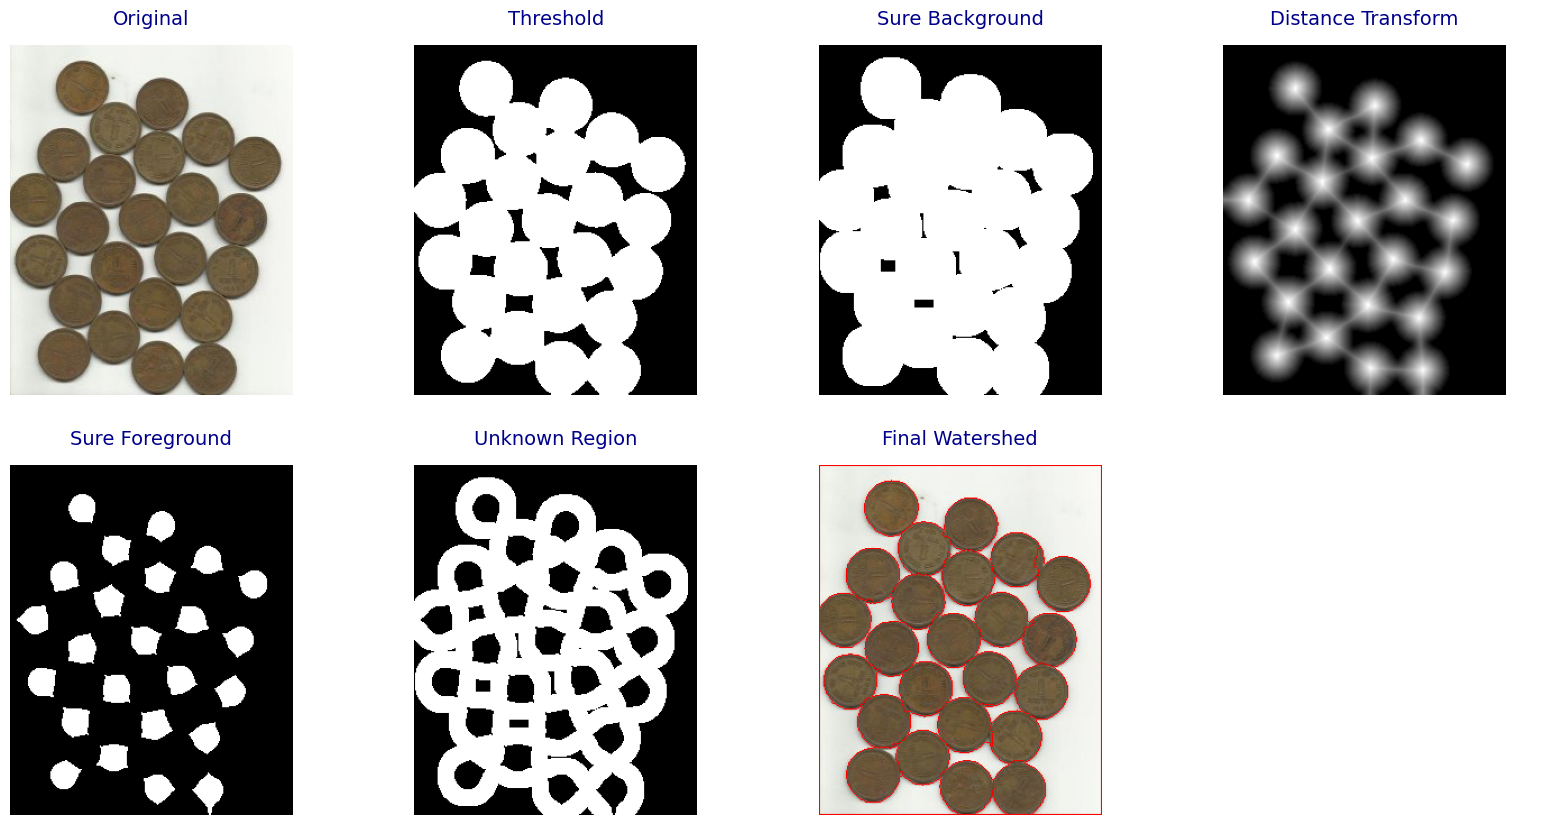

In [6]:
panels = [
    ('Original', img),
    ('Threshold', thresh),
    ('Sure Background', sure_bg),
    ('Distance Transform', dist),
    ('Sure Foreground', sure_fg),
    ('Unknown Region', unknown),
    ('Final Watershed', result),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

axes[-1].axis('off')
plt.show()

In [7]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task7_watershed.png', cv2.cvtColor(result, cv2.COLOR_RGB2BGR))

True

24 foreground markers and 24 regions. The red lines in the final image split the touching coins so each coin is its own region. The threshold image alone is one big connected area.